In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Sleep_Health_and_Lifestyle_Dataset.csv")  # path from notebooks folder

# Show first few rows
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [3]:
df['Sleep Duration'].unique()

array([6.1, 6.2, 5.9, 6.3, 7.8, 6. , 6.5, 7.6, 7.7, 7.9, 6.4, 7.5, 7.2,
       5.8, 6.7, 7.3, 7.4, 7.1, 6.6, 6.9, 8. , 6.8, 8.1, 8.3, 8.5, 8.4,
       8.2])

In [4]:
df['Sleep Duration'] = pd.to_numeric(df['Sleep Duration'], errors='coerce')


In [5]:
df = df[(df['Sleep Duration'] > 0) & (df['Sleep Duration'] <= 24)]

In [6]:
df['BMI Category'] = df['BMI Category'].str.strip().str.title()

In [7]:
df['Sleep Duration'].unique()
df['BMI Category'].unique()

array(['Overweight', 'Normal', 'Obese', 'Underweight'], dtype=object)

In [8]:
#cleaning the data
df_clean = df[['Sleep Duration', 'BMI Category']].dropna()
df_clean.head()

,Sleep Duration,BMI Category
0,6.1,Overweight
1,6.2,Normal
2,6.2,Normal
3,5.9,Obese
4,5.9,Obese


In [9]:
from scipy.stats import shapiro

groups = df_clean.groupby('BMI Category')

for cat, data in groups:
    stat, p = shapiro(data['Sleep Duration'])
    print(f"{cat}: p-value = {p:.4f}")

Normal: p-value = 0.0000
Obese: p-value = 0.0571
Overweight: p-value = 0.0000
Underweight: p-value = 0.2047


In [10]:
normal = df_clean[df_clean['BMI Category'] == 'Normal']['Sleep Duration']
obese = df_clean[df_clean['BMI Category'] == 'Obese']['Sleep Duration']
overweight = df_clean[df_clean['BMI Category'] == 'Overweight']['Sleep Duration']
underweight = df_clean[df_clean['BMI Category'] == 'Underweight']['Sleep Duration']

from scipy.stats import kruskal
stat, p = kruskal(normal, obese, overweight, underweight)

print("Kruskal-Wallis H-statistic =", stat)
print("p-value =", p)

Kruskal-Wallis H-statistic = 43.08996299478458
p-value = 2.355107999829044e-09


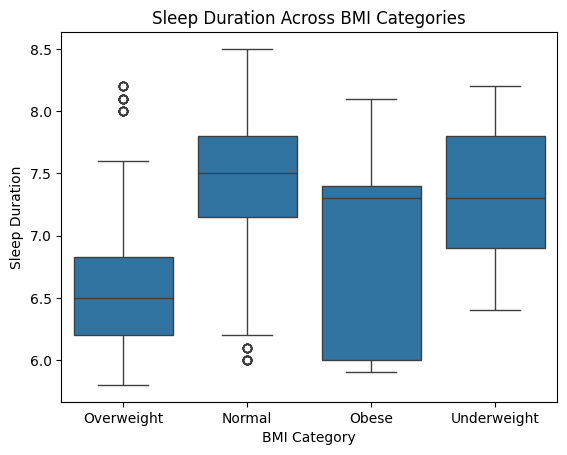

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='BMI Category', y='Sleep Duration', data=df_clean)
plt.title('Sleep Duration Across BMI Categories')
plt.show()

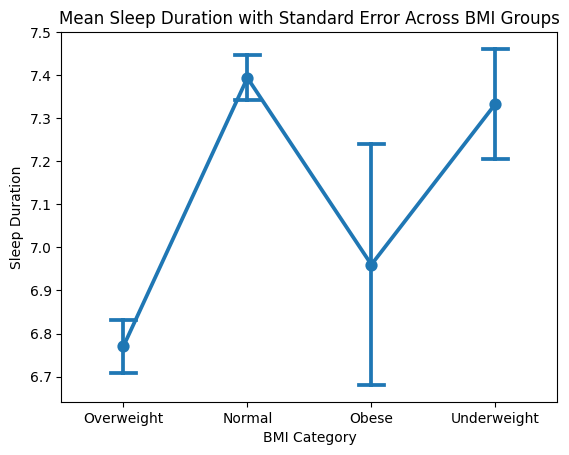

In [12]:
sns.pointplot(
    x='BMI Category',
    y='Sleep Duration',
    data=df_clean,
    capsize=0.2,
    errorbar='se'
)
plt.title("Mean Sleep Duration with Standard Error Across BMI Groups")
plt.show()